# Моделирование параметров прибытия подразделений пожарной охраны

## Общие сведения

Моделирование параметров прибытия подразделений пожарной охраны - одна из основных частей работы с библиотекой **Генезис**, в которой при помощи расчетных алгоритмов и с использованием исходных данных происходит моделирование параметров прибытия подразделений пожарной охраны.

Результатом моделирования является текущее состояние параметров прибытия пожарных подразделений - времена прибытия первого подразделения пожарной охраны во все узлы ГДС и идентификатор первого прибывающего подразделения пожарной охраны.

В наиболее общем виде структуру моделирования можно представить следующим образом:

```{mermaid}
flowchart LR

  state["**ФУНКЦИЯ МОДЕЛИРОВАНИЯ**"]

  source["**ИСХОДНЫЕ ДАННЫЕ**"]

  algs["**РАСЧЕТНЫЕ АЛГОРИТМЫ**
        ---
        Кратчайший путь
        ---
        Модель оценки t_сл"]


  model("**МОДЕЛИРОВАНИЕ
          ПАРАМЕТРОВ
          ПРИБЫТИЯ**")
  
  result["**РЕЗУЛЬТАТЫ**"]

  algs --> state
  state --> model
  source --> model
  model --> result

```

При конструировании решения пользователю, исходя из поставленной задачи расчета, необходимо: 

1. Выбрать функцию моделирования
2. Указать используемые функцией моделирования (*как правило достаточно установленных по умолчанию*):
  - алгоритм расчета кратчайшего пути
  - алгоритм расчета времени следования ПА
3. Выбрать исходные данные которые следует использовать:
  - ГДС *(всегда)*
  - дислокация ПСЧ
  - расчетная область
  - скоростной режим *(всегда)*

### Алгоритмы моделирования {.unnumbered}

В **Генезис** реализованы следующие алгоритмы:

- `genesis.states.FirstArrivalUnitState`: алгоритм расчета на основе определения времени прибытия от каждой указанной ПСЧ до каждого из узлов ГДС по кратчайшему маршруту (прямая задача)
- `genesis.states.ArrivalTimeMatrixState`: алгоритм расчета на основе заранее рассчитанной матрицы прибытия к каждому из узлов ГДС (обратная задача)

## Примеры использования

Загрузка основных библиотек

In [2]:
import random

import numpy as np
import osmnx as ox
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

import genesis as genesis


# Версии библиотек
print('OSMnx:', ox.__version__,
      '\nGeoPandas:', gpd.__version__,
      '\nPandas:', pd.__version__,
      '\ngenesis:', genesis.__version__,
      )

OSMnx: 2.0.1 
GeoPandas: 1.0.1 
Pandas: 2.2.2 
genesis: 0.1.035


### Загрузка исходных данных {.unnumbered}

In [3]:
from genesis.states import FirstArrivalUnitState
from graphs.speeds import set_graph_travel_times, kmh_to_mm
from fire_units.settings import DEFAULT_SPEEDS


# 1. Загрузка исходных данных
## Загрузка ГДС
G = ox.load_graphml('data/kemerovo/gds.ml')

## Загрузка пожарных подразделений
units = gpd.read_file('data/kemerovo/fire_units.gpkg')
### Сопоставление пожарных подразделений с ближайшими узлами ГДС
units['node'] = ox.distance.nearest_nodes(G, units.geometry.x, units.geometry.y)
### Формирование словаря подразделений для передачи алгоритму
units_dict = {k:v for k,v in zip(units['node'], units['name'])}

## Загрузка зданий
buildings = gpd.read_file('data/kemerovo/buildings.gpkg')
### Сопоставление зданий с ближайшими узлами ГДС
### Для полигональных объектов следует использовать центроиды: `geometry.centroid`
### Наборы данных желательно перепроецировать в локальную СК
centroids = ox.projection.project_gdf(buildings).geometry.centroid
buildings['node'] = ox.distance.nearest_nodes(ox.project_graph(G), 
                                              centroids.x,
                                              centroids.y
                                              )

## Загрузка границ населенного пункта
borders = gpd.read_file('data/kemerovo/borders.gpkg')


## Установка скоростного режима ГДС
set_graph_travel_times(
    G,
    speeds=DEFAULT_SPEEDS,
    morph_function = kmh_to_mm)


### Пример 1: Моделирование параметров прибытия во все узлы графа

**Задача**: Определить параметры прибытия подразделений пожарной охраны во все узлы ГДС

In [4]:
from genesis.states import FirstArrivalUnitState


# 2. Сборка решения
## Выбор алгоритма моделирования 
## (алгоритмы расчета расчета кратчайшего пути
## и времени следования установлены по умолчанию)
state = FirstArrivalUnitState()

# 3. Моделирование параметров прибытия
times, nearest = state(env=G, points=units_dict)


# Печать случайных 3 результатов по временам прибытия и ближайшим подразделениям
nodes = random.choices(times.keys(), k=3)
times[nodes], nearest[nodes]

(5529102501    10.288731
 2039713005    21.145816
 5120237832     7.832217
 Name: times, dtype: float64,
 5529102501    4 ПСЧ 1 ПСО ФПС ГПС ГУ МЧС России по Кемеровск...
 2039713005    2 ПСЧ 1 ПСО  ФПС ГПС ГУ МЧС России по Кемеровс...
 5120237832    1 ПСЧ 1 ПСО ФПС ГПС ГУ МЧС России по Кемеровск...
 Name: nearest, dtype: object)

`times` -- данные о временах прибытия первого подразделения пожарной охраны в каждый из узлов ГДС

`nearest` -- идентификатор первого прибывающего подразделения

Ключ, словаря - это идентификатор узла ГДС, значение - время прибытия первого подразделения и его идентификатор для `times` и `nearest`, соответственно. Таким образом `1025675392    11.725953`, означает что в узел `1025675392` первое подразделение прибудет через `6,5 минут`. А запись `(1025675392, "3 ПСЧ 1 ПСО ФПС ГПС ГУ МЧС России по Кемеровск...")` означает, что первым подразделением будет `3 ПСЧ 1 ПСО ФПС ГПС ГУ МЧС России по Кемеровск...`

:::{.callout-important}

#### Важно

На практике не всегда все узлы ГДС достижимы, поэтому количество `times` и `nearest` может быть меньше чем количество узлов графа

:::

Взглянуть на некоторые характеристики полученного распределения времен прибытия можно воспользовавшись `describe()`

In [4]:
times.describe()

count    54915.000000
mean        10.248943
std          5.993978
min          1.000000
25%          5.752797
50%          8.213621
75%         14.116574
max         35.690362
Name: times, dtype: float64

Видно, что среднее время прибытия первого пожарного подразделения составляет 10,2 мин, максимальное - 35,6 мин.

Графически оценить распределение времен прибытия можно построив гистограмму распределения.

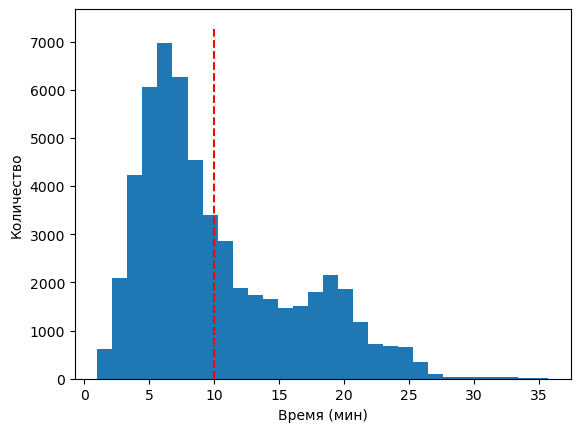

In [48]:
ax = times.plot(kind='hist', bins=30)
ax.set_xlabel('Время (мин)')
ax.set_ylabel('Количество')
ax.vlines(10, 0, ax.get_ylim()[1], colors='red', linestyles='dashed')

plt.show()

Можно также оценить долю значений, время прибытия которых превышает 10 и 20 минут (ИП-10 и ИП-20)

In [49]:
print('ИП-10:', 100 * sum(times<=10) / len(times))
print('ИП-10:', 100 * sum(times<=20) / len(times))

ИП-10: 60.92142401893836
ИП-10: 91.04069926249659


Наконец, очевидный интерес представляет визуализация времен прибытия и первого прибывшего подразделения пожарной охраны на карте населенного пункта.

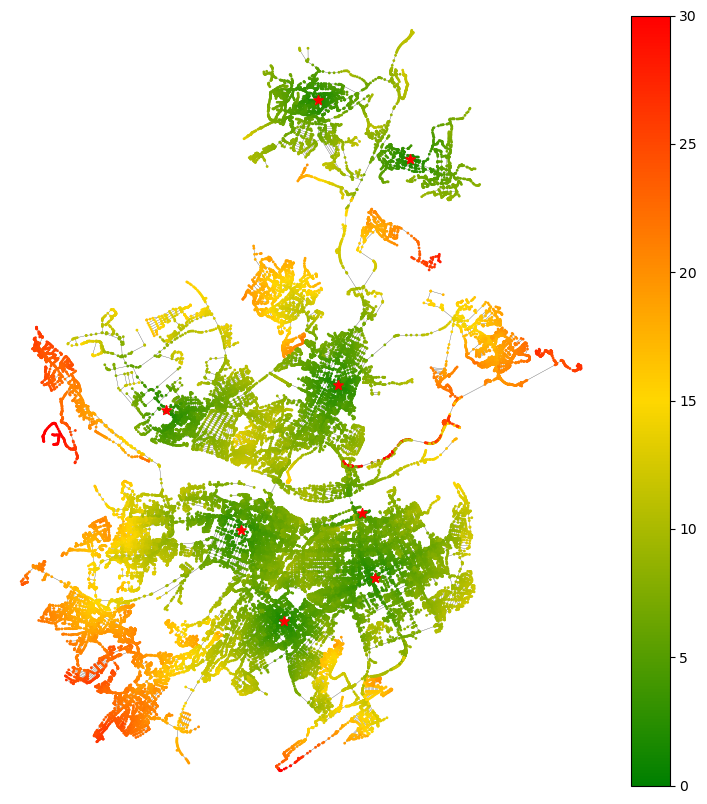

In [50]:
from genesis.swiss_knife import CMAP_GrGldRd    # Цветовая карта Зеленый-Красный

# Получение набора геоданных узлов ГДС
g_nodes = ox.graph_to_gdfs(G, edges=False)

# Дополняем геоданные результатами моделирования
g_nodes = g_nodes.merge(times, left_index=True, right_index=True)
g_nodes = g_nodes.merge(nearest, left_index=True, right_index=True)

# Печатаем узлы как градиент
fig, ax = plt.subplots(figsize=(10,10))
ox.plot_graph(G, node_size=0, edge_linewidth=0.2, edge_color='gray', ax=ax, close=False, show=False)
g_nodes.plot(column='times', ax=ax, cmap=CMAP_GrGldRd, markersize=1, vmin=0, vmax=30, label='Время прибытия', legend=True) 
units.plot(ax=ax, color='red', markersize=50, marker='*', label='Пожарные подразделения')

plt.show()

Однако интереснее было бы взглянуть на зоны прикрытые подразделениями пожарной охраны и зоны обслуживания ПСЧ

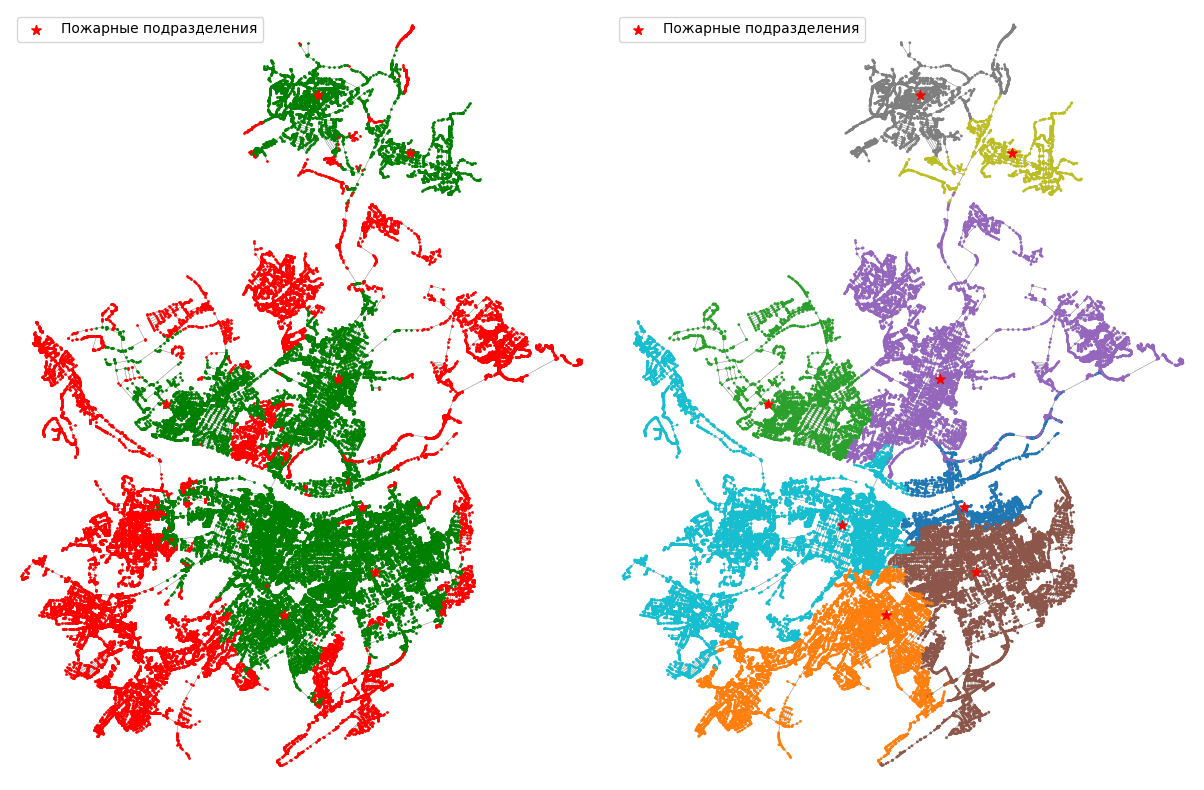

In [51]:
# Подготовка холста для 2 карт
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16,8), tight_layout=True)

# Карта 10 минутной зоны
ox.plot_graph(G, node_size=0, edge_linewidth=0.2, edge_color='gray', ax=ax1, close=False, show=False)
g_nodes[g_nodes['times']<=10].plot(ax=ax1, markersize=1, color='g') 
g_nodes[g_nodes['times']>10].plot(ax=ax1, markersize=1, color='r')
units.plot(ax=ax1, color='red', markersize=50, marker='*', label='Пожарные подразделения')
ax1.legend()

# Карта зон обслуживания
ox.plot_graph(G, node_size=0, edge_linewidth=0.2, edge_color='gray', ax=ax2, close=False, show=False)
g_nodes.plot(ax=ax2, column='nearest', markersize=1)
units.plot(ax=ax2, color='red', markersize=50, marker='*', label='Пожарные подразделения')
ax2.legend()

plt.show()

Боле подробно о способах визуализации карт при помощи Python можно прочитать в разделе "Для разработчиков".

### Пример 2: Моделирование в пределах некоторой области

Зачастую возникает ситуация когда требуется произвести расчет для некоторого населенного пункта и при этом необходимо учитывать возможность следования ПА за пределами населенного пункта. В такой ситуации нельзя учитывать узлы ГДС расположенные за пределами границ населенного пункта.

В этом случае необходимо указывать дополнительно маску узлов ГДС, которые следует учитывать в расчетах.

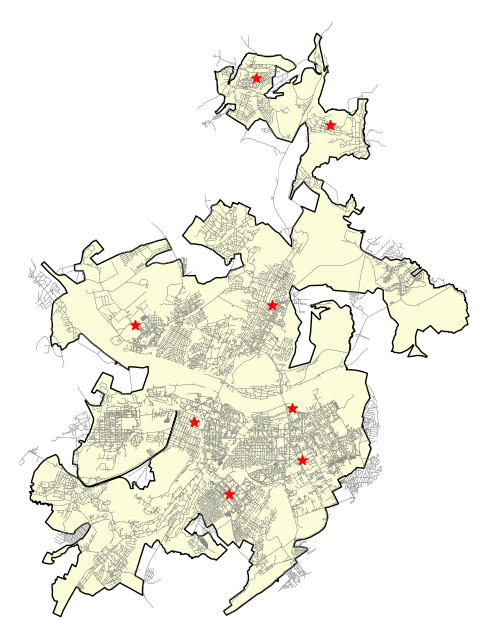

In [52]:
# Печать ГДС и границ населенного пункта
fig, ax = plt.subplots(figsize=(8,8))
borders.plot(ax=ax, color='#fcfcd9', edgecolor='black')
ox.plot_graph(G, node_size=0, edge_linewidth=0.2, edge_color='gray', ax=ax, close=False, show=False)
units.plot(ax=ax, color='red', markersize=50, marker='*', label='Пожарные подразделения')

plt.show()

Видно, что в данном случае часть ГДС находится за пределами границ населенного пункта и учитывать их в качестве возможных мест возникновения пожара тоже не требуется.

В этом случае моделирование выполняется только для узлов расположенных в пределах населенного пункта:

In [53]:
# Получение маски узлов графа (потенциальных мест возникновения пожара)
nodes_mask = g_nodes.within(borders.union_all())

# 3. Моделирование параметров прибытия
times, nearest = state(env=G, points=units_dict, area=nodes_mask)
times.describe()

count    48675.000000
mean         9.588211
std          5.566273
min          1.000000
25%          5.521719
50%          7.687040
75%         12.798064
max         33.472722
Name: times, dtype: float64

Видно, что размер `times` = 48675, в то время, как ранее размер результатов моделирования составлял 54915.

При этом теперь среднее время прибытия составляет 9,6 минут, против 10,2 минут ранее.

Взглянем как теперь выглядит карта населенного пункта:

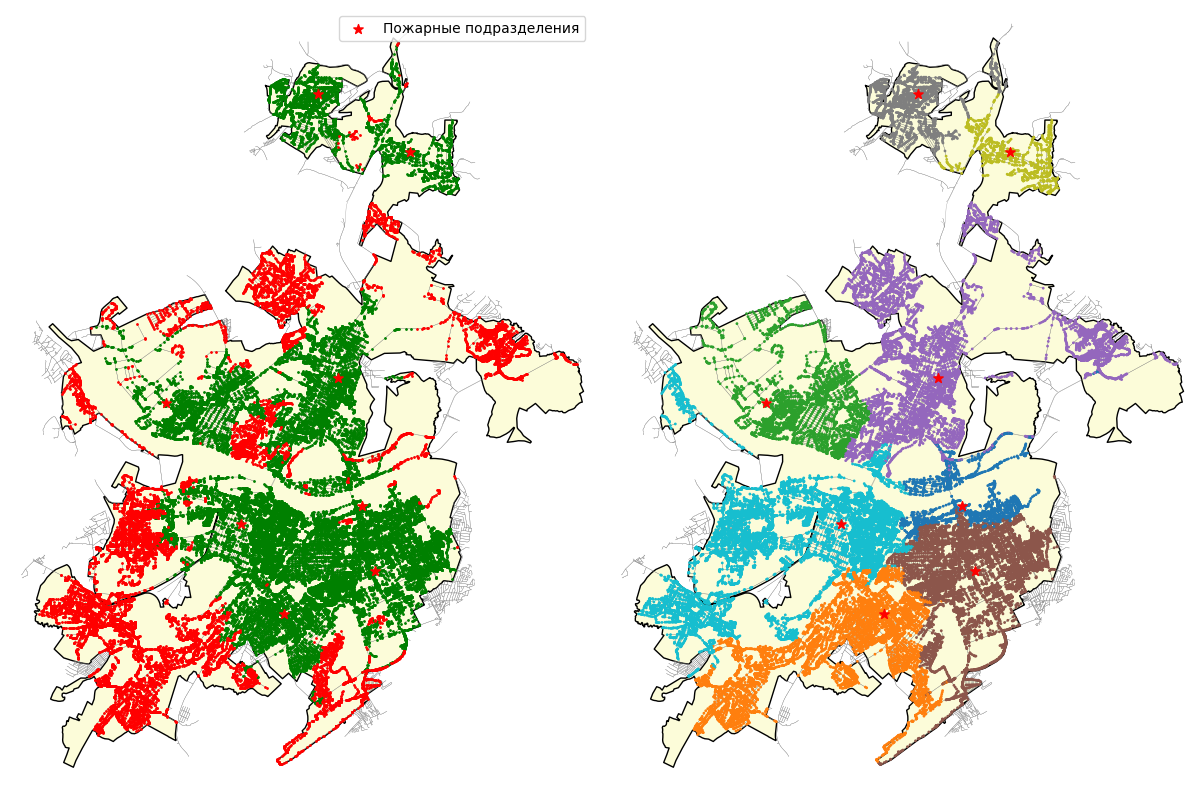

In [54]:
# Получение набора геоданных узлов ГДС
g_nodes = ox.graph_to_gdfs(G, edges=False)

# Дополняем геоданные результатами моделирования
g_nodes = g_nodes.merge(times, left_index=True, right_index=True)
g_nodes = g_nodes.merge(nearest, left_index=True, right_index=True)


# Подготовка холста для 2 карт
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16,8), tight_layout=True)

# Карта 10 минутной зоны
borders.plot(ax=ax1, color='#fcfcd9', edgecolor='black')
ox.plot_graph(G, node_size=0, edge_linewidth=0.2, edge_color='gray', ax=ax1, close=False, show=False)
g_nodes[g_nodes['times']<=10].plot(ax=ax1, markersize=1, color='g') 
g_nodes[g_nodes['times']>10].plot(ax=ax1, markersize=1, color='r')
units.plot(ax=ax1, color='red', markersize=50, marker='*', label='Пожарные подразделения')
ax1.legend()

# Карта зон обслуживания
borders.plot(ax=ax2, color='#fcfcd9', edgecolor='black')
ox.plot_graph(G, node_size=0, edge_linewidth=0.2, edge_color='gray', ax=ax2, close=False, show=False)
g_nodes.plot(ax=ax2, column='nearest', markersize=1)
units.plot(ax=ax2, color='red', markersize=50, marker='*', label='Пожарные подразделения')

plt.show()

Можно заметить, что узлы ГДС выходящие за пределы границ населенного пункта на карте теперь не отмечены.

### Пример 3: Моделирование параметров прибытия к зданиям

Реализованные в **Генезис** функции моделирования ориентированы на расчет времени прибытия к узлам ГДС. Предполагается, что дальнейший анализ будет выполняться либо инструментами анализа, либо внутренней логикой эвристических алгоритмов, либо пользователем.

Поэтому напрямую указать функциям моделирования здания в качестве цели нельзя.

Для моделирования параметров прибытия именно к зданиям населенного пункта, следует объединить набор пространственных данных о зданиях с результатами моделирования, аналогично тому, как выше происходило объединение с данными узлах ГДС.

In [55]:
from genesis.states import FirstArrivalUnitState


# 2. Сборка решения
## Выбор алгоритма моделирования 
## (алгоритмы расчета расчета кратчайшего пути
## и времени следования установлены по умолчанию)
state = FirstArrivalUnitState()


# 3. Моделирование параметров прибытия
times, nearest = state(env=G, points=units_dict)


# 4. Анализ результатов
# Дополнение данных о зданиях данными результатами моделирования (по полю `node`)
buildings_s = buildings.copy()
buildings_s = buildings_s.merge(times, left_on='node', right_index=True)
buildings_s = buildings_s.merge(nearest, left_on='node', right_index=True)

print('Результатов моделирования:', len(times))
print('Количество зданий:', len(buildings_s))

Результатов моделирования: 54915
Количество зданий: 37529


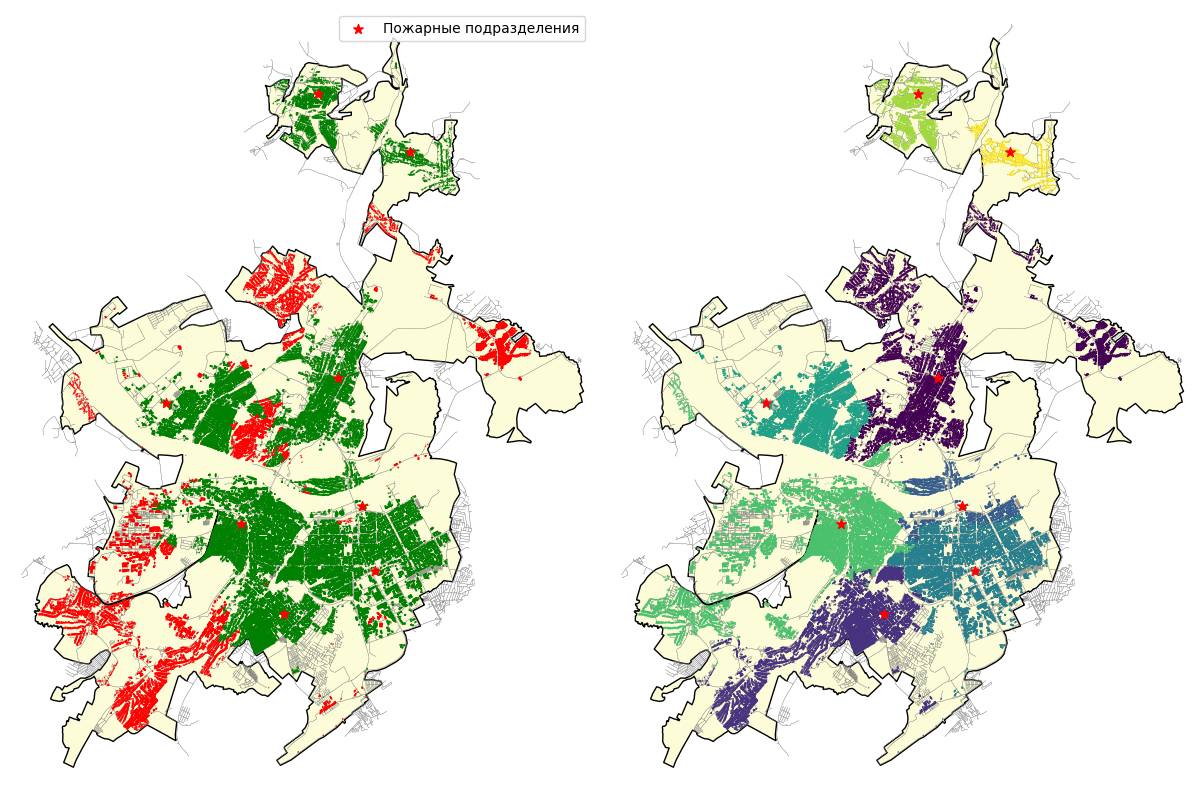

In [56]:
## Определение цветов зданий (требуется для лучшей читаемости при печати полигонов):
clrs = {k:v for k,v in zip(units['name'], ox.plot.get_colors(n=len(units)))}
bld_clrs = [clrs[n] for n in buildings_s['nearest']]


# Подготовка холста для 2 карт
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16,8), tight_layout=True)

# Карта 10 минутной зоны
borders.plot(ax=ax1, color='#fcfcd9', edgecolor='black')
ox.plot_graph(G, node_size=0, edge_linewidth=0.2, edge_color='gray', ax=ax1, close=False, show=False)
buildings_s[buildings_s['times']<=10].plot(ax=ax1, color='g', edgecolor='g') 
buildings_s[buildings_s['times']>10].plot(ax=ax1, color='r', edgecolor='r')
units.plot(ax=ax1, color='red', markersize=50, marker='*', label='Пожарные подразделения')
ax1.legend()

# Карта зон обслуживания
borders.plot(ax=ax2, color='#fcfcd9', edgecolor='black')
ox.plot_graph(G, node_size=0, edge_linewidth=0.2, edge_color='gray', ax=ax2, close=False, show=False)
buildings_s.plot(ax=ax2, facecolor=bld_clrs, edgecolor=bld_clrs)
units.plot(ax=ax2, color='red', markersize=50, marker='*', label='Пожарные подразделения')

plt.show()

### Пример 4: Настройки скоростного режима

Стандартный подход к настройке скоростного режима подразумевает разделение всех типов дорог на 5 классов:

Список скоростей для 5 классов дорог:

1. Магистральные городские дороги и улицы общегородского значения
2. Магистральные улицы районного значения
3. Улицы и дороги местного значения
4. Служебные проезды: внутриквартальные, въездные, парковочные и т.д.
5. Пешеходные зоны и территории не являющиеся проезжей частью,
    но теоретически пригодные для передвижения пожарных автомобилей
        
Для их установки используется функция `set_graph_travel_times()`.

:::{.callout-warning}

#### Важно

Единицы измерения для подачи в set_graph_travel_times - [м/мин]. 
Стандартные же скорости указаны в [км/ч]. 
Поэтому необходимо выполнять преобразование единиц измерения [км/ч] -> [м/мин]!

:::

Наиболее общий пример - использовать скорости по умолчанию (из `graphs.settings.DEFAULT_SPEEDS`).

    speeds = [kmh_to_mm(s) for s in DEFAULT_SPEEDS]
    set_graph_travel_times(G, speeds)

или:

    set_graph_travel_times(G, DEFAULT_SPEEDS, kmh_to_mm)

In [57]:
from fire_units.settings import DEFAULT_SPEEDS

# Печать скоростей следования по разным классам дорог:
print(DEFAULT_SPEEDS)

# Или:
print('Магистральные городские дороги и улицы общегородского значения:    ', DEFAULT_SPEEDS[0], 'км/ч')
print('Магистральные улицы районного значения:                            ', DEFAULT_SPEEDS[1], 'км/ч')
print('Улицы и дороги местного значения:                                  ', DEFAULT_SPEEDS[2], 'км/ч')
print('Служебные проезды: внутриквартальные, въездные, парковочные и т.д.:', DEFAULT_SPEEDS[3], 'км/ч')
print('Пешеходные зоны и территории не являющиеся проезжей частью и т.д.: ', DEFAULT_SPEEDS[4], 'км/ч')

[49, 37, 26, 16, 5]
Магистральные городские дороги и улицы общегородского значения:     49 км/ч
Магистральные улицы районного значения:                             37 км/ч
Улицы и дороги местного значения:                                   26 км/ч
Служебные проезды: внутриквартальные, въездные, парковочные и т.д.: 16 км/ч
Пешеходные зоны и территории не являющиеся проезжей частью и т.д.:  5 км/ч


Примеры преобразования к м/мин

In [58]:
# Стандартный скоростной режим
print('км/ч:  ', DEFAULT_SPEEDS)
print('м/мин: ', [kmh_to_mm(s) for s in DEFAULT_SPEEDS])
print('-'*80)

# Пользовательский скоростной режим
def_speeds = [50, 40, 30, 20, 10]
print('км/ч:  ', def_speeds)
print('м/мин: ', [kmh_to_mm(s) for s in def_speeds])

км/ч:   [49, 37, 26, 16, 5]
м/мин:  [816.67, 616.67, 433.33, 266.67, 83.33]
--------------------------------------------------------------------------------
км/ч:   [50, 40, 30, 20, 10]
м/мин:  [833.33, 666.67, 500.0, 333.33, 166.67]


Расчет для нескольких скоростных режимов:

In [59]:
from genesis.states import FirstArrivalUnitState
from graphs.speeds import set_graph_travel_times, kmh_to_mm
from fire_units.settings import DEFAULT_SPEEDS


# 2. Сборка решения
## Выбор алгоритма моделирования 
## (алгоритмы расчета расчета кратчайшего пути
## и времени следования установлены по умолчанию)
state = FirstArrivalUnitState()


# 3. Моделирование параметров прибытия
# 3.1. Скоростной режим DEFAULT_SPEEDS: [49, 37, 26, 16, 5]
print('Скоростной режим:', DEFAULT_SPEEDS)
set_graph_travel_times(
    G,
    speeds         = DEFAULT_SPEEDS,
    morph_function = kmh_to_mm)
times1, nearest1 = state(env=G, points=units_dict)
print(times1.describe(), end='\n\n')

# 3.2. Скоростной режим: [60, 45, 30, 15, 5]
print('Скоростной режим:', [60, 45, 30, 15, 5])
set_graph_travel_times(
    G,
    speeds         = [60, 45, 30, 15, 5],
    morph_function = kmh_to_mm)
times2, nearest2 = state(env=G, points=units_dict)
print(times2.describe(), end='\n\n')

# 3.3. Скоростной режим: [30, 25, 20, 15, 5]
print('Скоростной режим:', [30, 25, 20, 15, 5])
set_graph_travel_times(
    G,
    speeds         = [30, 25, 20, 15, 5],
    morph_function = kmh_to_mm)
times3, nearest3 = state(env=G, points=units_dict)
print(times3.describe(), end='\n\n')

Скоростной режим: [49, 37, 26, 16, 5]
count    54915.000000
mean        10.248943
std          5.993978
min          1.000000
25%          5.752797
50%          8.213621
75%         14.116574
max         35.690362
Name: times, dtype: float64

Скоростной режим: [60, 45, 30, 15, 5]
count    54915.000000
mean         8.940740
std          5.078279
min          1.000000
25%          5.108780
50%          7.226742
75%         12.423128
max         31.965563
Name: times, dtype: float64

Скоростной режим: [30, 25, 20, 15, 5]
count    54915.000000
mean        13.786360
std          8.474199
min          1.000000
25%          7.472917
50%         10.931034
75%         18.757200
max         48.919586
Name: times, dtype: float64



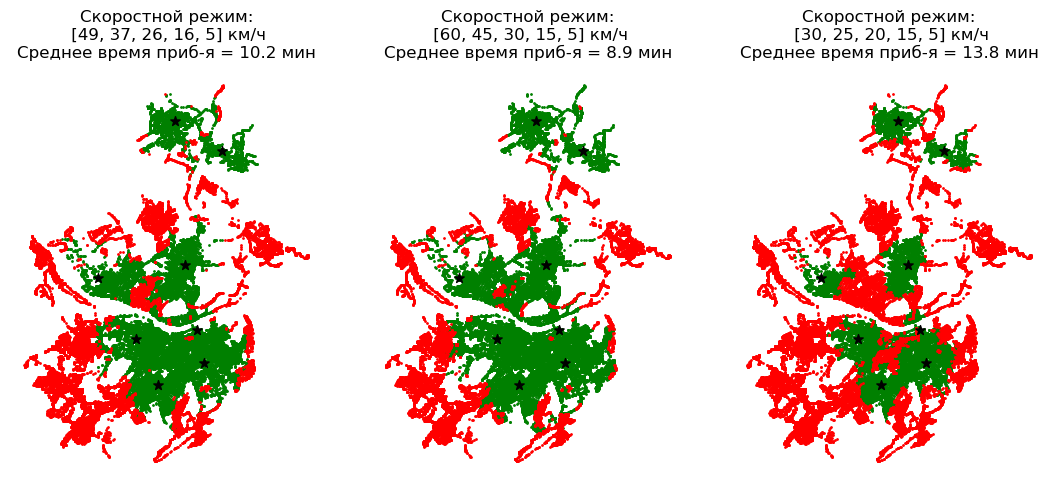

In [60]:
# Подготовка холста для 2 карт
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15,5), tight_layout=True)

# Карта скоростного режима 1
g_nodes = ox.graph_to_gdfs(G, edges=False)
g_nodes = g_nodes.merge(times1, left_index=True, right_index=True)

g_nodes[g_nodes['times']<=10].plot(ax=ax1, markersize=1, color='g') 
g_nodes[g_nodes['times']>10].plot(ax=ax1, markersize=1, color='r')
units.plot(ax=ax1, color='black', markersize=50, marker='*')
ax1.set_axis_off()
ax1.set_title(f'Скоростной режим:\n [49, 37, 26, 16, 5] км/ч\nСреднее время приб-я = {round(times1.mean(),1)} мин')


# Карта скоростного режима 2
g_nodes = ox.graph_to_gdfs(G, edges=False)
g_nodes = g_nodes.merge(times2, left_index=True, right_index=True)

g_nodes[g_nodes['times']<=10].plot(ax=ax2, markersize=1, color='g') 
g_nodes[g_nodes['times']>10].plot(ax=ax2, markersize=1, color='r')
units.plot(ax=ax2, color='black', markersize=50, marker='*')
ax2.set_axis_off()
ax2.set_title(f'Скоростной режим:\n [60, 45, 30, 15, 5] км/ч\nСреднее время приб-я = {round(times2.mean(),1)} мин')


# Карта скоростного режима 3
g_nodes = ox.graph_to_gdfs(G, edges=False)
g_nodes = g_nodes.merge(times3, left_index=True, right_index=True)

g_nodes[g_nodes['times']<=10].plot(ax=ax3, markersize=1, color='g') 
g_nodes[g_nodes['times']>10].plot(ax=ax3, markersize=1, color='r')
units.plot(ax=ax3, color='black', markersize=50, marker='*')
ax3.set_axis_off()
ax3.set_title(f'Скоростной режим:\n [30, 25, 20, 15, 5] км/ч\nСреднее время приб-я = {round(times3.mean(),1)} мин')

plt.show()

:::{.callout-note}

### К сведению

Здесь описан стандартный подход к изменению скоростного режима для 5 типов дорог. В случае если необходима более тонкая настройка скоростного режима рекомендуется обратиться к разделу "Для разработчиков".

:::

### Пример 5: Расчет матрицы прибытия

Для моделирования времени прибытия к объектам (обратная задача) предварительно требуется рассчитать матрицу прибытия - таблицу в которой строками являются идентификаторы узлов зданий, столбцами - идентификаторы узлов графа из которых можно попасть в каждое из зданий, в ячейках хранится числовое значение времени прибытия из каждого узла графа к каждому из зданий, либо значение `NaN`, означающее, что из узла $N_n$ нельзя попасть к зданию $B_n$, за заданное время (@tbl-atm-example).

|  | $N_1$ | $N_2$ | $N_3$ | ... | $N_n$ |
| - | ---- | ----- | ----- | --- | ----- |
| $B_1$ | 3,1 | 4,2 | 1,5 | ... | 7,5 |
| $B_2$ | 6,6 | `NaN` | 14,2 | ... | 3,3 |
| $B_3$ | 4,2 | 6,1 | `NaN` | ... | 12,3 |
| ... | ... | ... | ... | ... | ... |
| $B_n$ | 6,3 | `NaN` | `NaN` | ... | 2,1 |

: Пример матрицы прибытия {#tbl-atm-example}

В приведенном примере можно отметить, что узлом из которого можно попасть за 10 минут в наибольшее количество зданий является узел $N_1$.

Матрица рассчитывается при помощи функции `genesis.states.get_atm`:

#### Расчет для ограниченного размера выборки зданий {.unnumbered}

Ограничивать размер выборки рекомендуется для ускорения расчетов. При указании аргумента `data_sample_size` расчет будет произведен для указанного числа случайным образом выбранных объектов из `data`. 

Следует соблюдать разумный баланс между временем расчета и точностью -> чем больше доля используемых в расчете объектов, тем выше точность, но больше требуется времени, и наоборот.

In [61]:
from genesis.states import get_atm

matrix = get_atm(G, 
                 data             = buildings,
                 data_sample_size = 500,       # Размер выборки (чем меньше, тем быстрее расчет, но ниже точность)
                 )
print('Размер матрицы:', matrix.shape)
matrix

|########################################| 100.0%
Размер матрицы: (480, 54881)


,390613258,390613261,390613268,390613272,390613275,390613276,390613278,390613280,390613285,390613288,...,12829481034,12829481035,12829481036,12829481037,12829481038,12829481039,12829481040,12829481041,12829481042,12829481043
2024641135,20.383050,17.521600,18.097457,15.545990,18.205399,22.462102,14.594259,22.392188,17.882714,14.231209,...,12.992426,13.442471,13.414192,13.293285,13.132327,13.652121,13.814328,13.569400,13.727973,12.923331
11240578274,33.115864,36.278786,36.854643,36.644270,37.365615,26.793885,36.916489,29.574517,36.639900,35.726441,...,35.138654,35.588699,36.700075,36.579168,36.418210,35.798349,35.960556,35.715628,35.874201,35.069559
8127811507,13.418846,13.235045,13.810902,13.213030,14.321874,11.851778,16.584828,8.625932,13.596159,17.310683,...,20.302645,20.752690,21.011704,20.890797,20.729840,20.962340,21.124547,20.879619,21.038191,20.233550
8114377668,30.577376,29.783964,30.359821,29.761949,30.870793,29.873972,33.133747,25.784462,30.145079,33.859602,...,36.851564,37.301609,37.560623,37.439716,37.278759,37.511259,37.673466,37.428538,37.587111,36.782469
7385021598,14.940008,7.838954,8.414811,4.985886,8.925783,16.965076,14.284327,11.624384,8.200068,15.010183,...,16.283318,16.733363,16.705083,16.584176,16.423219,16.943013,17.105220,16.860292,17.018864,16.214223
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2643057504,19.341418,22.504339,23.080196,22.869824,23.591168,13.019439,19.051853,15.800071,22.865454,17.760215,...,15.349479,15.799524,16.910900,16.789993,16.629035,16.009174,16.171381,15.926453,16.085026,15.280385
1062486813,41.653605,44.816527,45.392384,45.182011,45.903356,35.331626,43.646781,38.112259,45.177641,42.355144,...,39.944407,40.394453,41.505828,41.384921,41.223963,40.604103,40.766310,40.521382,40.679954,39.875313
1433188650,5.912623,8.871319,9.447176,10.133216,9.958148,7.642122,11.535673,1.848379,9.232433,10.345625,...,13.530488,13.980533,15.091909,14.971002,14.810044,14.190183,14.352390,14.107462,14.266035,13.461394
2368216154,19.646445,16.070142,16.645999,14.094531,16.753941,21.919106,14.051263,21.655583,16.431256,13.688213,...,12.449430,12.899475,12.871196,12.750289,12.589331,13.109125,13.271332,13.026404,13.184977,12.380335


#### Расчет с ограничением времени прибытия {.unnumbered}

При установлении ограничения по времени прибытия расчет выполняется заметно быстрее, т.к. время прибытия вычисляется только для зон ограниченных заданным временем (в минутах).

In [62]:
matrix = get_atm(G, 
                 data   = buildings,
                 cutoff = 10,         # Ограничение по времени прибытия в минутах (сокращает время расчета)
                 )
print('Размер матрицы:', matrix.shape)

|########################################| 100.0%
Размер матрицы: (15459, 19858)


#### Расчет с ограничением по времени определенном для каждого здания {.unnumbered}

Данный подход может быть использован при проведении расчетов в соответствии с СП 11.13130.2009.

In [63]:
matrix = get_atm(G, 
                 data              = buildings,
                 data_sample_size  = 500,
                 data_cutoff_field = 'need_time',
                 )
print('Размер матрицы:', matrix.shape)

|########################################| 100.0%
Размер матрицы: (479, 46496)


Также возможно проводить моделирование по допустимому расстоянию от объекта предполагаемого пожара до ближайшего пожарного депо.

In [64]:
matrix = get_atm(G, 
                 data   = buildings,
                 cutoff = 1000,         # В данном случае передается значение в метрах
                 weight = 'length',
                 )
print('Размер матрицы:', matrix.shape)

|########################################| 100.0%
Размер матрицы: (15459, 23928)


В результате данные в матрице прибытия хранятся в метрах

In [65]:
matrix[:3]

,390613258,390613261,390613268,390613272,390613275,390613276,390613278,390613280,390613285,390613288,...,12829481034,12829481035,12829481036,12829481037,12829481038,12829481039,12829481040,12829481041,12829481042,12829481043
1014031143,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12713036988,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7083575982,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Пример 6: Моделирование времени прибытия к объектам

Функция `genesis.states.ArrivalTimeMatrixState` является основной при проведении расчетов с использованием алгоритма жадного добавления (ADD), в соответствии с требованиями СП 11.13130.2009.

Для ее применения требуется предварительно рассчитать матрицу прибытия с использованием функции `genesis.states.get_atm`.

In [5]:
from genesis.states import ArrivalTimeMatrixState, get_atm


# 2. Сборка решения
## Расчет матрицы прибытия
matrix = get_atm(G, 
                 data             = buildings,
                 data_sample_size = 500,       # Размер выборки (чем меньше, тем быстрее расчет, но ниже точность)
                 )

## Выбор алгоритма моделирования 
state = ArrivalTimeMatrixState(matrix)

# 3. Моделирование параметров прибытия
times, nearest = state(env=G, points=units_dict)


# 4. Анализ результатов
# Дополнение данных о зданиях данными результатами моделирования (по полю `node`)
buildings_s = buildings.copy()
buildings_s = buildings_s.merge(times, left_on='node', right_index=True)
buildings_s = buildings_s.merge(nearest, left_on='node', right_index=True)

print('Количество зданий в зоне обслуживания каждого из подразделений:')
buildings_s.groupby('nearest').count()['times']

|########################################| 100.0%
Количество зданий в зоне обслуживания каждого из подразделений:


nearest
1 ПСЧ 1 ПСО ФПС ГПС ГУ МЧС России по Кемеровской области - Кузбассу       113
2 ПСЧ 1 ПСО  ФПС ГПС ГУ МЧС России по Кемеровской области - Кузбассу      485
3 ПСЧ 1 ПСО ФПС ГПС ГУ МЧС России по Кемеровской области - Кузбассу       598
4 ПСЧ 1 ПСО ФПС ГПС ГУ МЧС России по Кемеровской области - Кузбассу       385
5 ПСЧ 1 ПСО ФПС ГПС ГУ МЧС России по Кемеровской области - Кузбассу       309
7 ПСЧ 1 ПСО ФПС ГПС ГУ МЧС России по Кемеровской области - Кузбассу       114
ОП 7 ПСЧ 1 ПСО ФПС ГПС ГУ МЧС России по Кемеровской области - Кузбассу     80
СПСЧ ФПС ГПС ГУ МЧС России по Кемеровской области - Кузбассу              528
Name: times, dtype: int64

:::{.callout-important}
### Важно 

Алгоритм моделирования `ArrivalTimeMatrixState(matrix)` используется в `LSCP_ADD` только в том случае, если при расчете матрицы прибытия **не было указано** ограничение времени прибытия `cutoff`.

Если же в функции `get_atm` **было указано** ограничение времени прибытия `cutoff` (так как в примере выше), то следует использовать алгоритм моделирования `FirstArrivalUnitState()`

:::

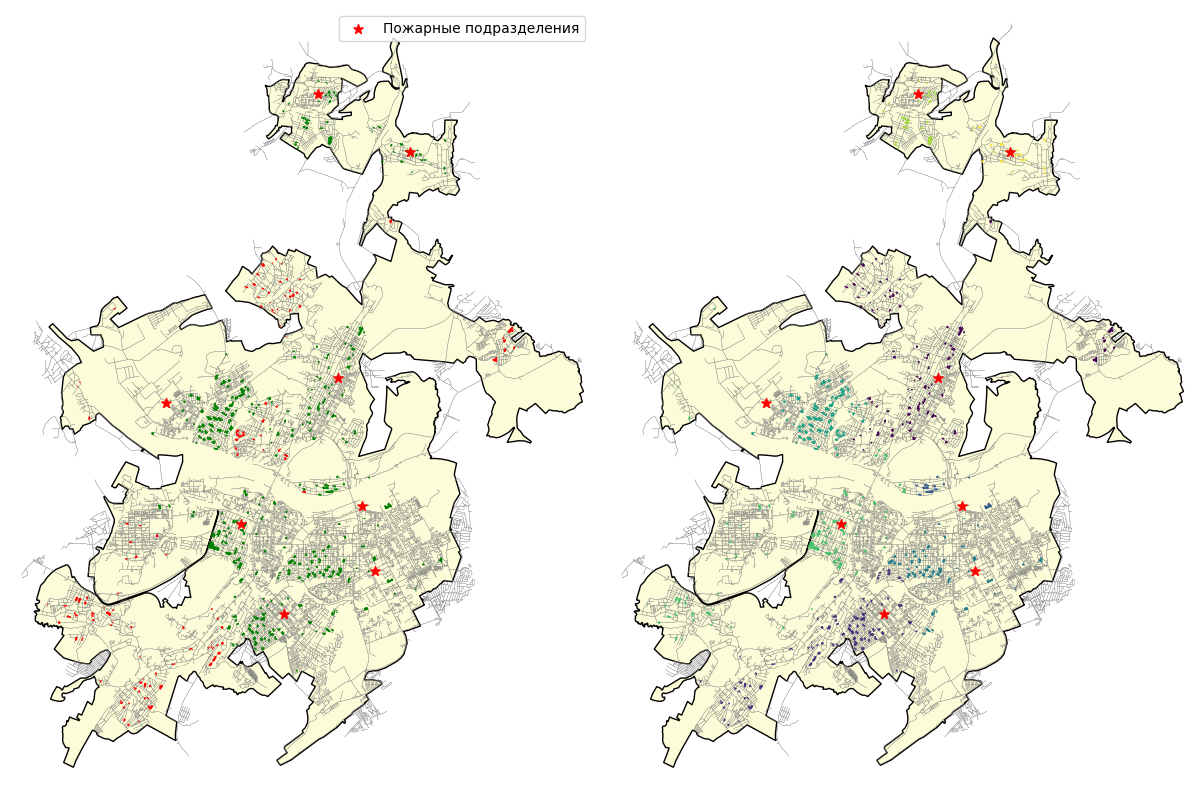

In [6]:
## Определение цветов зданий (требуется для лучшей читаемости при печати полигонов):
clrs = {k:v for k,v in zip(units['name'], ox.plot.get_colors(n=len(units)))}
bld_clrs = [clrs[n] for n in buildings_s['nearest']]


# Подготовка холста для 2 карт
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16,8), tight_layout=True)

# Карта 10 минутной зоны
borders.plot(ax=ax1, color='#fcfcd9', edgecolor='black')
ox.plot_graph(G, node_size=0, edge_linewidth=0.2, edge_color='gray', ax=ax1, close=False, show=False)
buildings_s[buildings_s['times']<=10].plot(ax=ax1, color='g', edgecolor='g') 
buildings_s[buildings_s['times']>10].plot(ax=ax1, color='r', edgecolor='r')
units.plot(ax=ax1, color='red', markersize=50, marker='*', label='Пожарные подразделения')
ax1.legend()

# Карта зон обслуживания
borders.plot(ax=ax2, color='#fcfcd9', edgecolor='black')
ox.plot_graph(G, node_size=0, edge_linewidth=0.2, edge_color='gray', ax=ax2, close=False, show=False)
buildings_s.plot(ax=ax2, facecolor=bld_clrs, edgecolor=bld_clrs)
units.plot(ax=ax2, color='red', markersize=50, marker='*', label='Пожарные подразделения')

plt.show()

:::{.callout-important}

#### Важно

При расчете матрицы следует помнить, что при указании аргумента `cutoff`, отвечающего за ограничение расчетной зоны может случиться ситуация, когда узлы некоторых ПСЧ могут не попасть в матрицу, т.к. ни в одно из переданных зданий нет пути позволяющего ПА добраться к зданию из места дислокации за `cutoff` минут. Для того чтобы избежать этой ошибки можно предпринять следующие действия:

1. Увеличить значение `cutoff`
2. Не указывать значение `cutoff`, в этом случае будет произведен расчет прибытия из всех доступных узлов
3. Увеличить значение `data_sample_size`
4. Не указывать `data_sample_size`, в этом случае будет произведен расчет для всех объектов в наборе `data`.

:::

### Пример 7: Моделирование времени прибытия к объектам в соответствии с СП 11.13130.2009

В соответствии с п. 4 СП 11.13130.2009 [@SP_11]:

> 4.3 Для каждого объекта предполагаемого пожара рассчитывается максимально допустимое расстояние от него до ближайшего пожарного депо в зависимости от цели выезда дежурного караула на пожар и выбранной схемы его развития. Максимально допустимое расстояние от объекта предполагаемого пожара до ближайшего пожарного депо определяется для одной или одновременно нескольких из нижеприведенных целей выезда подразделений пожарной охраны на пожар:

> - цель № 1: ликвидация пожара прежде, чем его площадь превысит площадь, которую может потушить один дежурный караул.

> -	цель № 2: ликвидация пожара прежде, чем наступит предел огнестойкости строительных конструкций в помещении пожара.

> -	цель № 3: ликвидация пожара прежде, чем опасные факторы пожара достигнут критических для жизни людей значений.

Таким образом, максимально допустимое расстояние от объекта до ближайшего пожарного депо может быть представлено в виде времени прибытия.

Предполагается, что данный параметр рассчитывается для каждого здания отдельно (с использованием отдельных решений), а в `get_atm` передается в качестве аргумента `data_cutoff_field`, указывающего на то в каком поле набора пространственных данных он хранятся.

:::{.callout-important}

#### Важно

Хотя в данном случае аргумент `cutoff` явно не указан, он тем не менее определяется исходя из значений указанных в поле `data_cutoff_field`. Поэтому данный подход не применим для оценки параметров прибытия подразделений пожарной охраны в целом в населенном пункте. Он применяется **только** для решения задач пространственной оптимизации дислокации (**BLP**, **MCLP**, **LSCP**), что описано в соответствующих разделах.

:::

In [7]:
from genesis.states import ArrivalTimeMatrixState, get_atm



# 2. Сборка решения
## Расчет матрицы прибытия
matrix = get_atm(G, 
                 data              = buildings,
                 data_sample_size  = 1000,        # Размер выборки (чем меньше, тем быстрее расчет, но ниже точность)
                 data_cutoff_field = 'need_time'  # Поле требуемого времени прибытия
                 )

## Выбор алгоритма моделирования 
state = ArrivalTimeMatrixState(matrix)

# 3. Моделирование параметров прибытия
times, nearest = state(env=G, points=units_dict)


# 4. Анализ результатов
# Дополнение данных о зданиях данными результатами моделирования (по полю `node`)
buildings_s = buildings.copy()
buildings_s = buildings_s.merge(times, left_on='node', right_index=True)
buildings_s = buildings_s.merge(nearest, left_on='node', right_index=True)

print('Количество зданий в зоне обслуживания каждого из подразделений:')
buildings_s.groupby('nearest').count()['times']

|########################################| 100.0%
Количество зданий в зоне обслуживания каждого из подразделений:


nearest
1 ПСЧ 1 ПСО ФПС ГПС ГУ МЧС России по Кемеровской области - Кузбассу       128
2 ПСЧ 1 ПСО  ФПС ГПС ГУ МЧС России по Кемеровской области - Кузбассу      489
3 ПСЧ 1 ПСО ФПС ГПС ГУ МЧС России по Кемеровской области - Кузбассу       644
4 ПСЧ 1 ПСО ФПС ГПС ГУ МЧС России по Кемеровской области - Кузбассу       550
5 ПСЧ 1 ПСО ФПС ГПС ГУ МЧС России по Кемеровской области - Кузбассу       421
7 ПСЧ 1 ПСО ФПС ГПС ГУ МЧС России по Кемеровской области - Кузбассу       212
ОП 7 ПСЧ 1 ПСО ФПС ГПС ГУ МЧС России по Кемеровской области - Кузбассу     99
СПСЧ ФПС ГПС ГУ МЧС России по Кемеровской области - Кузбассу              788
Name: times, dtype: int64

### Сохранение результатов моделирования

Во многих случаях бывает удобнее визуализировать и проводить анализ результатов моделирования в приложении QGIS. Для этого результаты можно сохранить в геопространственных форматах (предпочтительным является **GeoPackage**).

Для сохранения следует сопоставить результаты расчета с пространственными данными узлов ГДС или зданий.

In [7]:
# Дополнение данных о зданиях данными результатами моделирования (по полю `node`)
buildings_s = buildings.copy()
buildings_s = buildings_s.merge(times, left_on='node', right_index=True)
buildings_s = buildings_s.merge(nearest, left_on='node', right_index=True)

buildings_s.to_file('data/kemerovo/results.gpkg', layer='Параметры прибытия к зданиям')

In [8]:
g_nodes = ox.graph_to_gdfs(G, edges=False)
g_nodes = g_nodes.merge(times, left_index=True, right_index=True)
g_nodes = g_nodes.merge(nearest, left_index=True, right_index=True)

g_nodes.to_file('data/kemerovo/results.gpkg', layer='Параметры прибытия в узлы')